In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import os
import pyarrow


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",50)
pd.set_option("display.float_format","{:4f}".format)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
df=pd.read_csv("../data/raw/creditcard.csv")

print("SHAPE:",df.shape)
print()
print("COLUMNS",list(df.columns))
print()

print()
print("FIRST 3 ROWS: ")
print(df.head(3))

SHAPE: (284807, 31)

COLUMNS ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


FIRST 3 ROWS: 
      Time        V1        V2       V3       V4        V5        V6  \
0 0.000000 -1.359807 -0.072781 2.536347 1.378155 -0.338321  0.462388   
1 0.000000  1.191857  0.266151 0.166480 0.448154  0.060018 -0.082361   
2 1.000000 -1.358354 -1.340163 1.773209 0.379780 -0.503198  1.800499   

         V7       V8        V9       V10       V11       V12       V13  \
0  0.239599 0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390   
1 -0.078803 0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095   
2  0.791461 0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293   

        V14      V15       V16       V17       V18       V19       V20  \
0 -0.311169 1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412   
1 -0.

In [5]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Basic Stats ===")
df.describe().round(3)


=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,94813.860000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,88.350000,0.002000
std,47488.146000,1.959000,1.651000,1.516000,1.416000,1.380000,1.332000,1.237000,1.194000,1.099000,1.089000,1.021000,0.999000,0.995000,0.959000,0.915000,0.876000,0.849000,0.838000,0.814000,0.771000,0.735000,0.726000,0.624000,0.606000,0.521000,0.482000,0.404000,0.330000,250.120000,0.042000
min,0.000000,-56.408000,-72.716000,-48.326000,-5.683000,-113.743000,-26.161000,-43.557000,-73.217000,-13.434000,-24.588000,-4.797000,-18.684000,-5.792000,-19.214000,-4.499000,-14.130000,-25.163000,-9.499000,-7.214000,-54.498000,-34.830000,-10.933000,-44.808000,-2.837000,-10.295000,-2.605000,-22.566000,-15.430000,0.000000,0.000000
25%,54201.500000,-0.920000,-0.599000,-0.890000,-0.849000,-0.692000,-0.768000,-0.554000,-0.209000,-0.643000,-0.535000,-0.762000,-0.406000,-0.649000,-0.426000,-0.583000,-0.468000,-0.484000,-0.499000,-0.456000,-0.212000,-0.228000,-0.542000,-0.162000,-0.355000,-0.317000,-0.327000,-0.071000,-0.053000,5.600000,0.000000
50%,84692.000000,0.018000,0.065000,0.180000,-0.020000,-0.054000,-0.274000,0.040000,0.022000,-0.051000,-0.093000,-0.033000,0.140000,-0.014000,0.051000,0.048000,0.066000,-0.066000,-0.004000,0.004000,-0.062000,-0.029000,0.007000,-0.011000,0.041000,0.017000,-0.052000,0.001000,0.011000,22.000000,0.000000
75%,139320.500000,1.316000,0.804000,1.027000,0.743000,0.612000,0.399000,0.570000,0.327000,0.597000,0.454000,0.740000,0.618000,0.663000,0.493000,0.649000,0.523000,0.400000,0.501000,0.459000,0.133000,0.186000,0.529000,0.148000,0.440000,0.351000,0.241000,0.091000,0.078000,77.165000,0.000000
max,172792.000000,2.455000,22.058000,9.383000,16.875000,34.802000,73.302000,120.589000,20.007000,15.595000,23.745000,12.019000,7.848000,7.127000,10.527000,8.878000,17.315000,9.254000,5.041000,5.592000,39.421000,27.203000,10.503000,22.528000,4.585000,7.520000,3.517000,31.612000,33.848000,25691.160000,1.000000


In [6]:
fraud_count=int(df["Class"].sum())
total=len(df)
legit_count=total-fraud_count
fraud_pct=fraud_count/total*100

print("="*45)
print(f"TOTAL TRANSACTIONS : {total:,}")
print(f"LEGITIMATE         : {legit_count:,} ({(100-fraud_pct):.4f}%)")
print(f"FRAUDULENT         : {fraud_count:,} ({fraud_pct:.4f}%)")
print(f"IMBALANVE RATIO    :  1 fraud per{legit_count//fraud_count} legit")
print("="*45)

TOTAL TRANSACTIONS : 284,807
LEGITIMATE         : 284,315 (99.8273%)
FRAUDULENT         : 492 (0.1727%)
IMBALANVE RATIO    :  1 fraud per577 legit


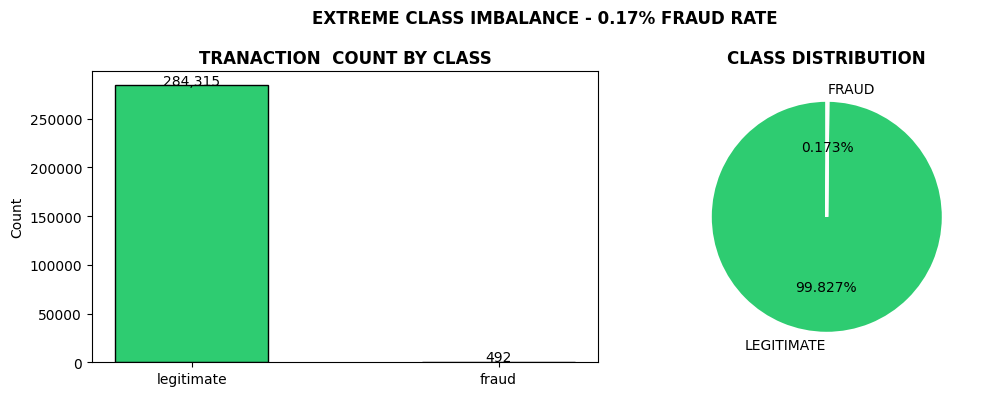

plot saves


In [7]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].bar(["legitimate","fraud"],
             [legit_count,fraud_count],
             color=["#2ecc71","#e74c3c"],
             width=0.5,edgecolor="black")
axes[0].set_title("TRANACTION  COUNT BY CLASS",fontweight="bold")
axes[0].set_ylabel("Count")
for bar,val in zip(axes[0].patches,[legit_count,fraud_count]):
    axes[0].text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+500,
    f"{val:,}",ha="center",fontsize=10)
axes[1].pie([legit_count,fraud_count],
             labels=["LEGITIMATE","FRAUD"],
             colors=["#2ecc71", "#e74c3c"],
             autopct="%1.3f%%",startangle=90,
             wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("CLASS DISTRIBUTION",fontweight="bold")
plt.suptitle("EXTREME CLASS IMBALANCE - 0.17% FRAUD RATE",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/01_classdistribution.png",dpi=150,bbox_inches="tight")
plt.show()
print("plot saves")


TRANSACTION AMOUNT

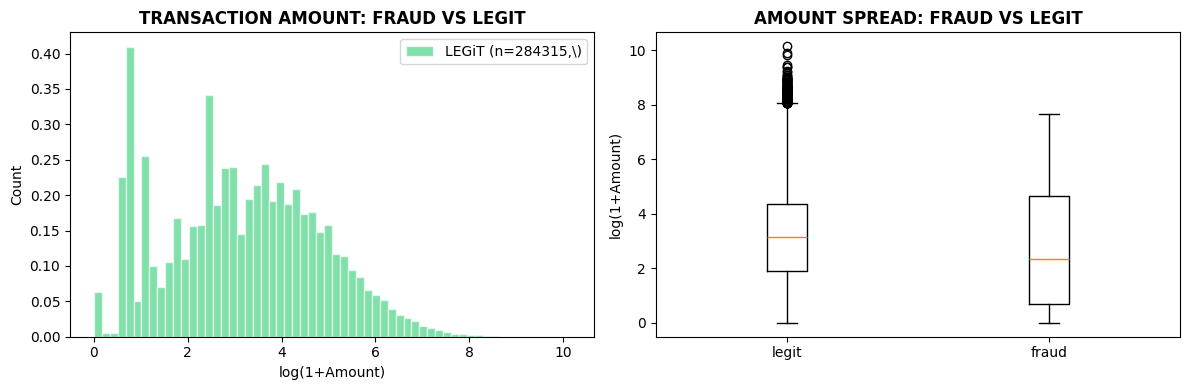


 AMOUNT STATS BY CLASS:
              count       mean        std      min      25%       50%  \
Class                                                                   
0     284315.000000  88.290000 250.110000 0.000000 5.650000 22.000000   
1        492.000000 122.210000 256.680000 0.000000 1.000000  9.250000   

             75%          max  
Class                          
0      77.050000 25691.160000  
1     105.890000  2125.870000  


<Figure size 640x480 with 0 Axes>


 AMOUNT STATS BY CLASS:
              count       mean        std      min      25%       50%  \
Class                                                                   
0     284315.000000  88.290000 250.110000 0.000000 5.650000 22.000000   
1        492.000000 122.210000 256.680000 0.000000 1.000000  9.250000   

             75%          max  
Class                          
0      77.050000 25691.160000  
1     105.890000  2125.870000  


In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

for label,color,name in [(0,"#2ecc71","LEGiT"),(1,"#e74c3c","FRAUD")]:
    data=df[df["Class"]==label]["Amount"]
    axes[0].hist(np.log1p(data),bins=60,alpha=0.6,density=True,
                 label=f"{name} (n={len(data)},\)",
                 color=color,edgecolor="white")
    axes[0].set_xlabel("log(1+Amount)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("TRANSACTION AMOUNT: FRAUD VS LEGIT",fontweight="bold")
    axes[0].legend()


    axes[1].boxplot(
        [
            np.log1p(df[df["Class"]==0]["Amount"]),
            np.log1p(df[df["Class"]==1]["Amount"])
        ],
        labels=["legit","fraud"]
    )

    axes[1].set_ylabel("log(1+Amount)")
    axes[1].set_title(
        "AMOUNT SPREAD: FRAUD VS LEGIT",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("../data/processed/02_transaction_amount.png",dpi=150,bbox_inches="tight")
    plt.show()

    print("\n AMOUNT STATS BY CLASS:")
    print(df.groupby("Class")["Amount"].describe().round(2))
    

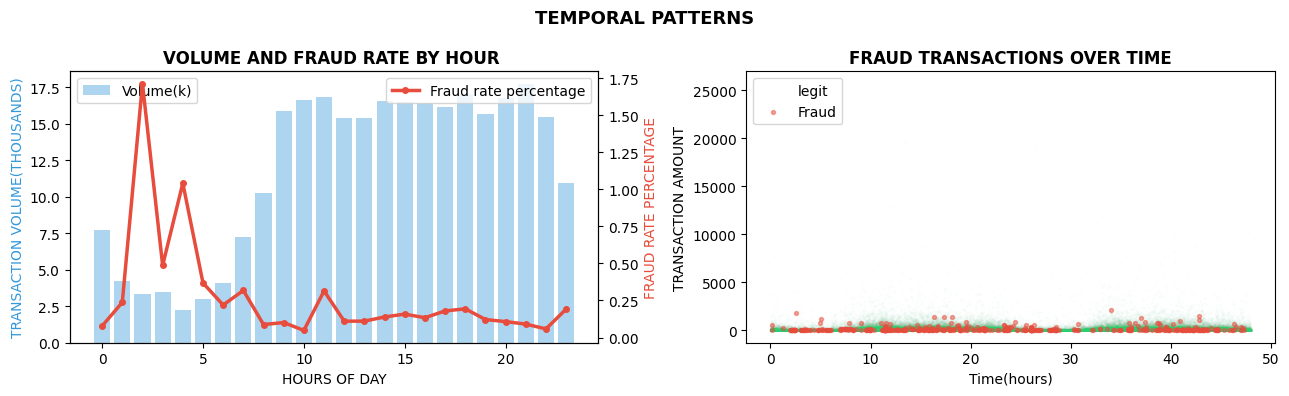

PEAK FRAUD HOUR: 2:00 (1.713% fraud rate)


In [31]:
df["hour"]=(df["Time"]//3600)%24
fig,axes=plt.subplots(1,2,figsize=(13,4))
hourly_vol=df.groupby("hour")["Class"].count()
hourly_fraud=df.groupby("hour")["Class"].mean()

ax2=axes[0].twinx()
axes[0].bar(hourly_vol.index,hourly_vol.values/1000,
            color="#3498db",alpha=0.4,label="Volume(k)")


ax2.plot(hourly_fraud.index,hourly_fraud.values * 100,
         color="#e74c3c",linewidth=2.5,
         marker="o",markersize=4,label="Fraud rate percentage")

axes[0].set_xlabel("HOURS OF DAY")
axes[0].set_ylabel("TRANSACTION VOLUME(THOUSANDS)",color="#3498db")
ax2.set_ylabel("FRAUD RATE PERCENTAGE",color="#e74c3c")
axes[0].set_title("VOLUME AND FRAUD RATE BY HOUR ",fontweight="bold")

axes[0].legend(loc="upper left")
ax2.legend(loc="upper right")


axes[1].scatter(
    df[df["Class"]==0]["Time"]/3600,
    df[df["Class"]==0]["Amount"],
    alpha=0.01,color="#2ecc71",s=1,label="legit"
)

axes[1].scatter(
    df[df["Class"]==1]["Time"]/3600,
    df[df["Class"]==1]["Amount"],
    alpha=0.5,color="#e74c3c",s=8,label="Fraud"
    )


axes[1].set_xlabel("Time(hours)")
axes[1].set_ylabel("TRANSACTION AMOUNT")
axes[1].set_title("FRAUD TRANSACTIONS OVER TIME",fontweight="bold")
axes[1].legend()

plt.suptitle("TEMPORAL PATTERNS",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/03_temporal_patterns.png",dpi=150,bbox_inches="tight")
plt.show()

peak_hour=int(hourly_fraud.idxmax())
print(f"PEAK FRAUD HOUR: {peak_hour}:00 ({hourly_fraud.max() * 100:.3f}% fraud rate)")

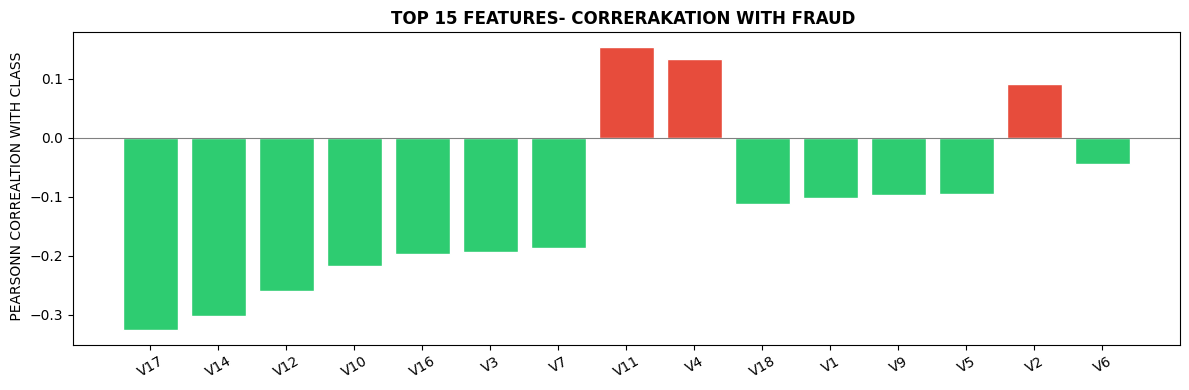


 MOST CORRELATED FEATURE: V17 (-0.326481)


In [36]:
v_features=[f"V{i}" for i in range(1,29)]

corr_with_fraud=df[v_features +["Amount","Class"]].corr()["Class"].drop("Class")
corr_sorted=corr_with_fraud.abs().sort_values(ascending=False)

plt.figure(figsize=(12,4))
top15=corr_with_fraud[corr_sorted.index[:15]]
colors=["#e74c3c" if v > 0 else "#2ecc71" for v in top15.values]
plt.bar(top15.index,top15.values,color=colors,edgecolor="white")
plt.axhline(0,color="grey",linewidth=0.8,)
plt.title("TOP 15 FEATURES- CORRERAKATION WITH FRAUD ",fontweight="bold")
plt.ylabel(" PEARSONN CORREALTION WITH CLASS")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../data/processed/04_feature_correlation.png",
            dpi=150,bbox_inches="tight"
            )
plt.show()
print(f"\n MOST CORRELATED FEATURE: {corr_sorted.index[0]} ({corr_with_fraud[corr_sorted.index[0]]:4f})")


In [9]:
os.makedirs("../data/processed",exist_ok=True)
df.to_parquet("../data/processed/creditcard_clean.parquet",index=False)

size_mb=os.path.getsize("../data/processed/creditcard_clean.parquet")/1e6
print(f"SAVED: creditcard_clean.parquet")
print(f"SHAPE:{df.shape}")
print(f"SIZE: {size_mb:.1f} MB")

SAVED: creditcard_clean.parquet
SHAPE:(284807, 31)
SIZE: 72.5 MB


## EDA Summary — Day 1

- Total transactions: ___
- Fraud transactions: ___ (___%)
- Legit transactions: ___
- Missing values: 0 (clean dataset)
- Peak fraud hour: ___
- Most correlated feature with fraud: ___

## What I noticed:
- (write 2-3 things you found interesting)

## Day 2 plan:
- Scale Amount and Time (V features are already scaled via PCA)
- Apply SMOTE to fix 0.17% imbalance
- Train/val/test split
- Build feature pipeline